# Part 0: Imports and Setup

## 0a. Enviornment Setup

In [684]:
!pip install utils

## 0b: Imports

In [685]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from PIL import Image
import torch
from torch import nn
from torch.nn import functional as F
import random
from contextlib import contextmanager
from typing import Union, Sequence, Tuple
import copy
import utils
import argparse
import pickle
import h5py

# vocal.pkl fix
import sys
sys.modules['data.vocab'] = sys.modules['__main__']

# Set seed for reproducability
torch.manual_seed(320)
np.random.seed(320)
random.seed(320)

## 0c: Github Code

All code in section *0c: Github Code* was taken from the [meshed-memory transformer github](https://github.com/aimagelab/meshed-memory-transformer/tree/master?tab=readme-ov-file). Any changes made to code here has been noted through inline comments.

---

```
@inproceedings{cornia2020m2,
  title={{Meshed-Memory Transformer for Image Captioning}},
  author={Cornia, Marcella and Stefanini, Matteo and Baraldi, Lorenzo and Cucchiara, Rita},
  booktitle={Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition},
  year={2020}
}
```

### utils.py
Provides utility functions, supporting suppressing stdout output and choosing a tokenizer.

In [686]:
import contextlib, sys

class DummyFile(object):
    def write(self, x): pass

@contextlib.contextmanager
def nostdout():
    save_stdout = sys.stdout
    sys.stdout = DummyFile()
    yield
    sys.stdout = save_stdout

def reporthook(t):
    """https://github.com/tqdm/tqdm"""
    last_b = [0]

    def inner(b=1, bsize=1, tsize=None):
        """
        b: int, optionala
        Number of blocks just transferred [default: 1].
        bsize: int, optional
        Size of each block (in tqdm units) [default: 1].
        tsize: int, optional
        Total size (in tqdm units). If [default: None] remains unchanged.
        """
        if tsize is not None:
            t.total = tsize
        t.update((b - last_b[0]) * bsize)
        last_b[0] = b
    return inner

def get_tokenizer(tokenizer):
    if callable(tokenizer):
        return tokenizer
    if tokenizer == "spacy":
        try:
            import spacy
            spacy_en = spacy.load('en_core_web_sm')
            return lambda s: [tok.text for tok in spacy_en.tokenizer(s)]
        except ImportError:
            print("Please install SpaCy and the SpaCy English tokenizer. "
                  "See the docs at https://spacy.io for more information.")
            raise
        except AttributeError:
            print("Please install SpaCy and the SpaCy English tokenizer. "
                  "See the docs at https://spacy.io for more information.")
            raise
    elif tokenizer == "moses":
        try:
            from nltk.tokenize.moses import MosesTokenizer
            moses_tokenizer = MosesTokenizer()
            return moses_tokenizer.tokenize
        except ImportError:
            print("Please install NLTK. "
                  "See the docs at http://nltk.org for more information.")
            raise
        except LookupError:
            print("Please install the necessary NLTK corpora. "
                  "See the docs at http://nltk.org for more information.")
            raise
    elif tokenizer == 'revtok':
        try:
            import revtok
            return revtok.tokenize
        except ImportError:
            print("Please install revtok.")
            raise
    elif tokenizer == 'subword':
        try:
            import revtok
            return lambda x: revtok.tokenize(x, decap=True)
        except ImportError:
            print("Please install revtok.")
            raise
    raise ValueError("Requested tokenizer {}, valid choices are a "
                     "callable that takes a single string as input, "
                     "\"revtok\" for the revtok reversible tokenizer, "
                     "\"subword\" for the revtok caps-aware tokenizer, "
                     "\"spacy\" for the SpaCy English tokenizer, or "
                     "\"moses\" for the NLTK port of the Moses tokenization "
                     "script.".format(tokenizer))

### added from utils/__init.py__ ###
def get_batch_size(x: Union[Sequence[torch.Tensor], torch.Tensor]) -> int:
    if isinstance(x, torch.Tensor):
        b_s = x.size(0)
    else:
        b_s = x[0].size(0)
    return b_s

### added from utils/__init.py__ ###
def get_device(x: Union[Sequence[torch.Tensor], torch.Tensor]) -> int:
    if isinstance(x, torch.Tensor):
        b_s = x.device
    else:
        b_s = x[0].device
    return b_s

### example.py
Defines a single training or test example. Stores each column of the example as an attribute.

In [687]:
class Example(object):
    """Defines a single training or test example.
    Stores each column of the example as an attribute.
    """
    @classmethod
    def fromdict(cls, data):
        ex = cls(data)
        return ex

    def __init__(self, data):
        for key, val in data.items():
            super(Example, self).__setattr__(key, val)

    def __setattr__(self, key, value):
        raise AttributeError

    def __hash__(self):
        return hash(tuple(x for x in self.__dict__.values()))

    def __eq__(self, other):
        this = tuple(x for x in self.__dict__.values())
        other = tuple(x for x in other.__dict__.values())
        return this == other

    def __ne__(self, other):
        return not self.__eq__(other)


### vocab.py
This file handles text token-to-index mappings, and associates them with pretrained word vectors. The `Vocab` class represents the mapping from words to indices and vice versa. The `Vectors` class is a base class used for working with the pretrained embeddings.


In [688]:
from __future__ import unicode_literals
import array
from collections import defaultdict, Counter
from functools import partial
import io
import logging
import os
import zipfile

import six
from six.moves.urllib.request import urlretrieve
import torch
from tqdm import tqdm
import tarfile

# from .utils import reporthook

logger = logging.getLogger(__name__)


class Vocab(object):
    """Defines a vocabulary object that will be used to numericalize a field.

    Attributes:
        freqs: A collections.Counter object holding the frequencies of tokens
            in the data used to build the Vocab.
        stoi: A collections.defaultdict instance mapping token strings to
            numerical identifiers.
        itos: A list of token strings indexed by their numerical identifiers.
    """
    def __init__(self, counter, max_size=None, min_freq=1, specials=['<pad>'],
                 vectors=None, unk_init=None, vectors_cache=None):
        """Create a Vocab object from a collections.Counter.

        Arguments:
            counter: collections.Counter object holding the frequencies of
                each value found in the data.
            max_size: The maximum size of the vocabulary, or None for no
                maximum. Default: None.
            min_freq: The minimum frequency needed to include a token in the
                vocabulary. Values less than 1 will be set to 1. Default: 1.
            specials: The list of special tokens (e.g., padding or eos) that
                will be prepended to the vocabulary in addition to an <unk>
                token. Default: ['<pad>']
            vectors: One of either the available pretrained vectors
                or custom pretrained vectors (see Vocab.load_vectors);
                or a list of aforementioned vectors
            unk_init (callback): by default, initialize out-of-vocabulary word vectors
                to zero vectors; can be any function that takes in a Tensor and
                returns a Tensor of the same size. Default: torch.Tensor.zero_
            vectors_cache: directory for cached vectors. Default: '.vector_cache'
        """
        self.freqs = counter
        counter = counter.copy()
        min_freq = max(min_freq, 1)

        self.itos = list(specials)
        # frequencies of special tokens are not counted when building vocabulary
        # in frequency order
        for tok in specials:
            del counter[tok]

        max_size = None if max_size is None else max_size + len(self.itos)

        # sort by frequency, then alphabetically
        words_and_frequencies = sorted(counter.items(), key=lambda tup: tup[0])
        words_and_frequencies.sort(key=lambda tup: tup[1], reverse=True)

        for word, freq in words_and_frequencies:
            if freq < min_freq or len(self.itos) == max_size:
                break
            self.itos.append(word)

        self.stoi = defaultdict(_default_unk_index)
        # stoi is simply a reverse dict for itos
        self.stoi.update({tok: i for i, tok in enumerate(self.itos)})

        self.vectors = None
        if vectors is not None:
            self.load_vectors(vectors, unk_init=unk_init, cache=vectors_cache)
        else:
            assert unk_init is None and vectors_cache is None

    def __eq__(self, other):
        if self.freqs != other.freqs:
            return False
        if self.stoi != other.stoi:
            return False
        if self.itos != other.itos:
            return False
        if self.vectors != other.vectors:
            return False
        return True

    def __len__(self):
        return len(self.itos)

    def extend(self, v, sort=False):
        words = sorted(v.itos) if sort else v.itos
        for w in words:
            if w not in self.stoi:
                self.itos.append(w)
                self.stoi[w] = len(self.itos) - 1

    def load_vectors(self, vectors, **kwargs):
        """
        Arguments:
            vectors: one of or a list containing instantiations of the
                GloVe, CharNGram, or Vectors classes. Alternatively, one
                of or a list of available pretrained vectors:
                charngram.100d
                fasttext.en.300d
                fasttext.simple.300d
                glove.42B.300d
                glove.840B.300d
                glove.twitter.27B.25d
                glove.twitter.27B.50d
                glove.twitter.27B.100d
                glove.twitter.27B.200d
                glove.6B.50d
                glove.6B.100d
                glove.6B.200d
                glove.6B.300d
            Remaining keyword arguments: Passed to the constructor of Vectors classes.
        """
        if not isinstance(vectors, list):
            vectors = [vectors]
        for idx, vector in enumerate(vectors):
            if six.PY2 and isinstance(vector, str):
                vector = six.text_type(vector)
            if isinstance(vector, six.string_types):
                # Convert the string pretrained vector identifier
                # to a Vectors object
                if vector not in pretrained_aliases:
                    raise ValueError(
                        "Got string input vector {}, but allowed pretrained "
                        "vectors are {}".format(
                            vector, list(pretrained_aliases.keys())))
                vectors[idx] = pretrained_aliases[vector](**kwargs)
            elif not isinstance(vector, Vectors):
                raise ValueError(
                    "Got input vectors of type {}, expected str or "
                    "Vectors object".format(type(vector)))

        tot_dim = sum(v.dim for v in vectors)
        self.vectors = torch.Tensor(len(self), tot_dim)
        for i, token in enumerate(self.itos):
            start_dim = 0
            for v in vectors:
                end_dim = start_dim + v.dim
                self.vectors[i][start_dim:end_dim] = v[token.strip()]
                start_dim = end_dim
            assert(start_dim == tot_dim)

    def set_vectors(self, stoi, vectors, dim, unk_init=torch.Tensor.zero_):
        """
        Set the vectors for the Vocab instance from a collection of Tensors.

        Arguments:
            stoi: A dictionary of string to the index of the associated vector
                in the `vectors` input argument.
            vectors: An indexed iterable (or other structure supporting __getitem__) that
                given an input index, returns a FloatTensor representing the vector
                for the token associated with the index. For example,
                vector[stoi["string"]] should return the vector for "string".
            dim: The dimensionality of the vectors.
            unk_init (callback): by default, initialize out-of-vocabulary word vectors
                to zero vectors; can be any function that takes in a Tensor and
                returns a Tensor of the same size. Default: torch.Tensor.zero_
        """
        self.vectors = torch.Tensor(len(self), dim)
        for i, token in enumerate(self.itos):
            wv_index = stoi.get(token, None)
            if wv_index is not None:
                self.vectors[i] = vectors[wv_index]
            else:
                self.vectors[i] = unk_init(self.vectors[i])


class Vectors(object):

    def __init__(self, name, cache=None,
                 url=None, unk_init=None):
        """
        Arguments:
           name: name of the file that contains the vectors
           cache: directory for cached vectors
           url: url for download if vectors not found in cache
           unk_init (callback): by default, initalize out-of-vocabulary word vectors
               to zero vectors; can be any function that takes in a Tensor and
               returns a Tensor of the same size
         """
        cache = '.vector_cache' if cache is None else cache
        self.unk_init = torch.Tensor.zero_ if unk_init is None else unk_init
        self.cache(name, cache, url=url)

    def __getitem__(self, token):
        if token in self.stoi:
            return self.vectors[self.stoi[token]]
        else:
            return self.unk_init(torch.Tensor(self.dim))  # self.unk_init(torch.Tensor(1, self.dim))

    def cache(self, name, cache, url=None):
        if os.path.isfile(name):
            path = name
            path_pt = os.path.join(cache, os.path.basename(name)) + '.pt'
        else:
            path = os.path.join(cache, name)
            path_pt = path + '.pt'

        if not os.path.isfile(path_pt):
            if not os.path.isfile(path) and url:
                logger.info('Downloading vectors from {}'.format(url))
                if not os.path.exists(cache):
                    os.makedirs(cache)
                dest = os.path.join(cache, os.path.basename(url))
                if not os.path.isfile(dest):
                    with tqdm(unit='B', unit_scale=True, miniters=1, desc=dest) as t:
                        try:
                            urlretrieve(url, dest, reporthook=reporthook(t))
                        except KeyboardInterrupt as e:  # remove the partial zip file
                            os.remove(dest)
                            raise e
                logger.info('Extracting vectors into {}'.format(cache))
                ext = os.path.splitext(dest)[1][1:]
                if ext == 'zip':
                    with zipfile.ZipFile(dest, "r") as zf:
                        zf.extractall(cache)
                elif ext == 'gz':
                    with tarfile.open(dest, 'r:gz') as tar:
                        tar.extractall(path=cache)
            if not os.path.isfile(path):
                raise RuntimeError('no vectors found at {}'.format(path))

            # str call is necessary for Python 2/3 compatibility, since
            # argument must be Python 2 str (Python 3 bytes) or
            # Python 3 str (Python 2 unicode)
            itos, vectors, dim = [], array.array(str('d')), None

            # Try to read the whole file with utf-8 encoding.
            binary_lines = False
            try:
                with io.open(path, encoding="utf8") as f:
                    lines = [line for line in f]
            # If there are malformed lines, read in binary mode
            # and manually decode each word from utf-8
            except:
                logger.warning("Could not read {} as UTF8 file, "
                               "reading file as bytes and skipping "
                               "words with malformed UTF8.".format(path))
                with open(path, 'rb') as f:
                    lines = [line for line in f]
                binary_lines = True

            logger.info("Loading vectors from {}".format(path))
            for line in tqdm(lines, total=len(lines)):
                # Explicitly splitting on " " is important, so we don't
                # get rid of Unicode non-breaking spaces in the vectors.
                entries = line.rstrip().split(b" " if binary_lines else " ")

                word, entries = entries[0], entries[1:]
                if dim is None and len(entries) > 1:
                    dim = len(entries)
                elif len(entries) == 1:
                    logger.warning("Skipping token {} with 1-dimensional "
                                   "vector {}; likely a header".format(word, entries))
                    continue
                elif dim != len(entries):
                    raise RuntimeError(
                        "Vector for token {} has {} dimensions, but previously "
                        "read vectors have {} dimensions. All vectors must have "
                        "the same number of dimensions.".format(word, len(entries), dim))

                if binary_lines:
                    try:
                        if isinstance(word, six.binary_type):
                            word = word.decode('utf-8')
                    except:
                        logger.info("Skipping non-UTF8 token {}".format(repr(word)))
                        continue
                vectors.extend(float(x) for x in entries)
                itos.append(word)

            self.itos = itos
            self.stoi = {word: i for i, word in enumerate(itos)}
            self.vectors = torch.Tensor(vectors).view(-1, dim)
            self.dim = dim
            logger.info('Saving vectors to {}'.format(path_pt))
            if not os.path.exists(cache):
                os.makedirs(cache)
            torch.save((self.itos, self.stoi, self.vectors, self.dim), path_pt)
        else:
            logger.info('Loading vectors from {}'.format(path_pt))
            self.itos, self.stoi, self.vectors, self.dim = torch.load(path_pt)


class GloVe(Vectors):
    url = {
        '42B': 'http://nlp.stanford.edu/data/glove.42B.300d.zip',
        '840B': 'http://nlp.stanford.edu/data/glove.840B.300d.zip',
        'twitter.27B': 'http://nlp.stanford.edu/data/glove.twitter.27B.zip',
        '6B': 'http://nlp.stanford.edu/data/glove.6B.zip',
    }

    def __init__(self, name='840B', dim=300, **kwargs):
        url = self.url[name]
        name = 'glove.{}.{}d.txt'.format(name, str(dim))
        super(GloVe, self).__init__(name, url=url, **kwargs)


class FastText(Vectors):

    url_base = 'https://s3-us-west-1.amazonaws.com/fasttext-vectors/wiki.{}.vec'

    def __init__(self, language="en", **kwargs):
        url = self.url_base.format(language)
        name = os.path.basename(url)
        super(FastText, self).__init__(name, url=url, **kwargs)


class CharNGram(Vectors):

    name = 'charNgram.txt'
    url = ('http://www.logos.t.u-tokyo.ac.jp/~hassy/publications/arxiv2016jmt/'
           'jmt_pre-trained_embeddings.tar.gz')

    def __init__(self, **kwargs):
        super(CharNGram, self).__init__(self.name, url=self.url, **kwargs)

    def __getitem__(self, token):
        vector = torch.Tensor(1, self.dim).zero_()
        if token == "<unk>":
            return self.unk_init(vector)
        # These literals need to be coerced to unicode for Python 2 compatibility
        # when we try to join them with read ngrams from the files.
        chars = ['#BEGIN#'] + list(token) + ['#END#']
        num_vectors = 0
        for n in [2, 3, 4]:
            end = len(chars) - n + 1
            grams = [chars[i:(i + n)] for i in range(end)]
            for gram in grams:
                gram_key = '{}gram-{}'.format(n, ''.join(gram))
                if gram_key in self.stoi:
                    vector += self.vectors[self.stoi[gram_key]]
                    num_vectors += 1
        if num_vectors > 0:
            vector /= num_vectors
        else:
            vector = self.unk_init(vector)
        return vector


def _default_unk_index():
    return 0


pretrained_aliases = {
    "charngram.100d": partial(CharNGram),
    "fasttext.en.300d": partial(FastText, language="en"),
    "fasttext.simple.300d": partial(FastText, language="simple"),
    "glove.42B.300d": partial(GloVe, name="42B", dim="300"),
    "glove.840B.300d": partial(GloVe, name="840B", dim="300"),
    "glove.twitter.27B.25d": partial(GloVe, name="twitter.27B", dim="25"),
    "glove.twitter.27B.50d": partial(GloVe, name="twitter.27B", dim="50"),
    "glove.twitter.27B.100d": partial(GloVe, name="twitter.27B", dim="100"),
    "glove.twitter.27B.200d": partial(GloVe, name="twitter.27B", dim="200"),
    "glove.6B.50d": partial(GloVe, name="6B", dim="50"),
    "glove.6B.100d": partial(GloVe, name="6B", dim="100"),
    "glove.6B.200d": partial(GloVe, name="6B", dim="200"),
    "glove.6B.300d": partial(GloVe, name="6B", dim="300")
}
"""Mapping from string name to factory function"""


'Mapping from string name to factory function'

### dataset.py
This file defines the dataset abstraction layer for image captioning. It handles how examples are loaded, how to organize them into training/validation/test splits, how batches are collated for training, and how to format and group examples by keys (like `image_id`). `Dataset` is a baseclass the wraps a list of `Examples` and `Fields`. `ValueDataset` is used with `DictionaryDataset` to store multiple values sharing a single key. `DictionaryDataset` is a datset where examples are group by keys. `PairedDataset` is a set of image-caption pairs that's used as the standard for image captioning tasks. The `COCO` class is a subset of `PairedDataset` that is specialized to load COCO captions and image paths.

In [689]:
import os
import numpy as np
import itertools
import collections.abc as collections
import torch
# from .example import Example
# from .utils import nostdout
from pycocotools.coco import COCO as pyCOCO
from torch.utils.data import DataLoader as TorchDataLoader

class Dataset(object):
    def __init__(self, examples, fields):
        self.examples = examples
        self.fields = dict(fields)

    def collate_fn(self):
        def collate(batch):
            if len(self.fields) == 1:
                batch = [batch, ]
            else:
                batch = list(zip(*batch))

            tensors = []
            for field, data in zip(self.fields.values(), batch):
                tensor = field.process(data)
                if isinstance(tensor, collections.Sequence) and any(isinstance(t, torch.Tensor) for t in tensor):
                    tensors.extend(tensor)
                else:
                    tensors.append(tensor)

            if len(tensors) > 1:
                return tensors
            else:
                return tensors[0]

        return collate

    def __getitem__(self, i):
        example = self.examples[i]
        data = []
        for field_name, field in self.fields.items():
            data.append(field.preprocess(getattr(example, field_name)))

        if len(data) == 1:
            data = data[0]
        return data

    def __len__(self):
        return len(self.examples)

    # def __getattr__(self, attr):
    #     if attr in self.fields:
    #         for x in self.examples:
    #             yield getattr(x, attr)


class ValueDataset(Dataset):
    def __init__(self, examples, fields, dictionary):
        self.dictionary = dictionary
        super(ValueDataset, self).__init__(examples, fields)

    def collate_fn(self):
        def collate(batch):
            value_batch_flattened = list(itertools.chain(*batch))
            value_tensors_flattened = super(ValueDataset, self).collate_fn()(value_batch_flattened)

            lengths = [0, ] + list(itertools.accumulate([len(x) for x in batch]))
            if isinstance(value_tensors_flattened, collections.Sequence) \
                    and any(isinstance(t, torch.Tensor) for t in value_tensors_flattened):
                value_tensors = [[vt[s:e] for (s, e) in zip(lengths[:-1], lengths[1:])] for vt in value_tensors_flattened]
            else:
                value_tensors = [value_tensors_flattened[s:e] for (s, e) in zip(lengths[:-1], lengths[1:])]

            return value_tensors
        return collate

    def __getitem__(self, i):
        if i not in self.dictionary:
            raise IndexError

        values_data = []
        for idx in self.dictionary[i]:
            value_data = super(ValueDataset, self).__getitem__(idx)
            values_data.append(value_data)
        return values_data

    def __len__(self):
        return len(self.dictionary)


class DictionaryDataset(Dataset):
    def __init__(self, examples, fields, key_fields):
        if not isinstance(key_fields, (tuple, list)):
            key_fields = (key_fields,)
        for field in key_fields:
            assert (field in fields)

        dictionary = collections.defaultdict(list)
        key_fields = {k: fields[k] for k in key_fields}
        value_fields = {k: fields[k] for k in fields.keys() if k not in key_fields}
        key_examples = []
        key_dict = dict()
        value_examples = []

        for i, e in enumerate(examples):
            key_example = Example.fromdict({k: getattr(e, k) for k in key_fields})
            value_example = Example.fromdict({v: getattr(e, v) for v in value_fields})
            if key_example not in key_dict:
                key_dict[key_example] = len(key_examples)
                key_examples.append(key_example)

            value_examples.append(value_example)
            dictionary[key_dict[key_example]].append(i)

        self.key_dataset = Dataset(key_examples, key_fields)
        self.value_dataset = ValueDataset(value_examples, value_fields, dictionary)
        super(DictionaryDataset, self).__init__(examples, fields)

    def collate_fn(self):
        def collate(batch):
            key_batch, value_batch = list(zip(*batch))
            key_tensors = self.key_dataset.collate_fn()(key_batch)
            value_tensors = self.value_dataset.collate_fn()(value_batch)
            return key_tensors, value_tensors
        return collate

    def __getitem__(self, i):
        return self.key_dataset[i], self.value_dataset[i]

    def __len__(self):
        return len(self.key_dataset)


def unique(sequence):
    seen = set()
    if isinstance(sequence[0], list):
        return [x for x in sequence if not (tuple(x) in seen or seen.add(tuple(x)))]
    else:
        return [x for x in sequence if not (x in seen or seen.add(x))]


class PairedDataset(Dataset):
    def __init__(self, examples, fields):
        assert ('image' in fields)
        assert ('text' in fields)
        super(PairedDataset, self).__init__(examples, fields)
        self.image_field = self.fields['image']
        self.text_field = self.fields['text']

    def image_set(self):
        img_list = [e.image for e in self.examples]
        image_set = unique(img_list)
        examples = [Example.fromdict({'image': i}) for i in image_set]
        dataset = Dataset(examples, {'image': self.image_field})
        return dataset

    def text_set(self):
        text_list = [e.text for e in self.examples]
        text_list = unique(text_list)
        examples = [Example.fromdict({'text': t}) for t in text_list]
        dataset = Dataset(examples, {'text': self.text_field})
        return dataset

    def image_dictionary(self, fields=None):
        if not fields:
            fields = self.fields
        dataset = DictionaryDataset(self.examples, fields, key_fields='image')
        return dataset

    def text_dictionary(self, fields=None):
        if not fields:
            fields = self.fields
        dataset = DictionaryDataset(self.examples, fields, key_fields='text')
        return dataset

    @property
    def splits(self):
        raise NotImplementedError


class COCO(PairedDataset):
    def __init__(self, image_field, text_field, img_root, ann_root, id_root=None, use_restval=True,
                 cut_validation=False):
        roots = {}
        roots['train'] = {
            'img': os.path.join(img_root, 'train2014'),
            'cap': os.path.join(ann_root, 'captions_train2014.json')
        }
        roots['val'] = {
            'img': os.path.join(img_root, 'val2014'),
            'cap': os.path.join(ann_root, 'captions_val2014.json')
        }
        roots['test'] = {
            'img': os.path.join(img_root, 'val2014'),
            'cap': os.path.join(ann_root, 'captions_val2014.json')
        }
        roots['trainrestval'] = {
            'img': (roots['train']['img'], roots['val']['img']),
            'cap': (roots['train']['cap'], roots['val']['cap'])
        }

        if id_root is not None:
            ids = {}
            ids['train'] = np.load(os.path.join(id_root, 'coco_train_ids.npy'))
            ids['val'] = np.load(os.path.join(id_root, 'coco_dev_ids.npy'))
            if cut_validation:
                ids['val'] = ids['val'][:5000]
            ids['test'] = np.load(os.path.join(id_root, 'coco_test_ids.npy'))
            ids['trainrestval'] = (
                ids['train'],
                np.load(os.path.join(id_root, 'coco_restval_ids.npy')))

            if use_restval:
                roots['train'] = roots['trainrestval']
                ids['train'] = ids['trainrestval']
        else:
            ids = None

        with nostdout():
            self.train_examples, self.val_examples, self.test_examples = self.get_samples(roots, ids)
        examples = self.train_examples + self.val_examples + self.test_examples
        super(COCO, self).__init__(examples, {'image': image_field, 'text': text_field})

    @property
    def splits(self):
        train_split = PairedDataset(self.train_examples, self.fields)
        val_split = PairedDataset(self.val_examples, self.fields)
        test_split = PairedDataset(self.test_examples, self.fields)
        return train_split, val_split, test_split

    @classmethod
    def get_samples(cls, roots, ids_dataset=None):
        train_samples = []
        val_samples = []
        test_samples = []

        for split in ['train', 'val', 'test']:
            if isinstance(roots[split]['cap'], tuple):
                coco_dataset = (pyCOCO(roots[split]['cap'][0]), pyCOCO(roots[split]['cap'][1]))
                root = roots[split]['img']
            else:
                coco_dataset = (pyCOCO(roots[split]['cap']),)
                root = (roots[split]['img'],)

            if ids_dataset is None:
                ids = list(coco_dataset.anns.keys())
            else:
                ids = ids_dataset[split]

            if isinstance(ids, tuple):
                bp = len(ids[0])
                ids = list(ids[0]) + list(ids[1])
            else:
                bp = len(ids)

            for index in range(len(ids)):
                if index < bp:
                    coco = coco_dataset[0]
                    img_root = root[0]
                else:
                    coco = coco_dataset[1]
                    img_root = root[1]

                ann_id = ids[index]
                caption = coco.anns[ann_id]['caption']
                img_id = coco.anns[ann_id]['image_id']
                filename = coco.loadImgs(img_id)[0]['file_name']

                example = Example.fromdict({'image': os.path.join(img_root, filename), 'text': caption})

                if split == 'train':
                    train_samples.append(example)
                elif split == 'val':
                    val_samples.append(example)
                elif split == 'test':
                    test_samples.append(example)

        return train_samples, val_samples, test_samples

### added from data/__init__.py ###
class DataLoader(TorchDataLoader):
    def __init__(self, dataset, *args, **kwargs):
        super(DataLoader, self).__init__(dataset, *args, collate_fn=dataset.collate_fn(), **kwargs)


### containers.py
`Module` serves as a wrapper around the nn.Module that adds support for managing persistent state across time steps which is required for the decoding process.

In [690]:
class Module(nn.Module):
    def __init__(self):
        super(Module, self).__init__()
        self._is_stateful = False
        self._state_names = []
        self._state_defaults = dict()

    def register_state(self, name: str, default: Union[torch.Tensor, None]):
        self._state_names.append(name)
        if default is None:
            self._state_defaults[name] = None
        else:
            self._state_defaults[name] = default.clone().detach()
        self.register_buffer(name, default)

    def states(self):
        for name in self._state_names:
            yield self._buffers[name]
        for m in self.children():
            if isinstance(m, Module):
                yield from m.states()

    def apply_to_states(self, fn):
        for name in self._state_names:
            self._buffers[name] = fn(self._buffers[name])
        for m in self.children():
            if isinstance(m, Module):
                m.apply_to_states(fn)

    def _init_states(self, batch_size: int):
        for name in self._state_names:
            if self._state_defaults[name] is None:
                self._buffers[name] = None
            else:
                self._buffers[name] = self._state_defaults[name].clone().detach().to(self._buffers[name].device)
                self._buffers[name] = self._buffers[name].unsqueeze(0)
                self._buffers[name] = self._buffers[name].expand([batch_size, ] + list(self._buffers[name].shape[1:]))
                self._buffers[name] = self._buffers[name].contiguous()

    def _reset_states(self):
        for name in self._state_names:
            if self._state_defaults[name] is None:
                self._buffers[name] = None
            else:
                self._buffers[name] = self._state_defaults[name].clone().detach().to(self._buffers[name].device)

    def enable_statefulness(self, batch_size: int):
        for m in self.children():
            if isinstance(m, Module):
                m.enable_statefulness(batch_size)
        self._init_states(batch_size)
        self._is_stateful = True

    def disable_statefulness(self):
        for m in self.children():
            if isinstance(m, Module):
                m.disable_statefulness()
        self._reset_states()
        self._is_stateful = False

    @contextmanager
    def statefulness(self, batch_size: int):
        self.enable_statefulness(batch_size)
        try:
            yield
        finally:
            self.disable_statefulness()


class ModuleList(nn.ModuleList, Module):
    pass


class ModuleDict(nn.ModuleDict, Module):
    pass


### field.py
Classes in this file help with the preprocessing steps for input data. `TextField` handles textual data (e.g. captions) by tokenizing sentences, adding special tokens for beginning of sentence (`<bos>`) and end of sentence (`<eos>`), padding and truncating length, and mapping inputs to tensors and vice versa. `ImageDetectionsField` handles image region features stored in .hdf5 a file type. `Merge` combines multiple fields into one, making it easy to puar an image with its caption.

In [691]:
from collections import Counter, OrderedDict
from torch.utils.data.dataloader import default_collate
from itertools import chain
import six
import torch
import numpy as np
import h5py
import os
import warnings
import shutil

# from .utils import get_tokenizer


class RawField(object):
    """ Defines a general datatype.

    Every dataset consists of one or more types of data. For instance,
    a machine translation dataset contains paired examples of text, while
    an image captioning dataset contains images and texts.
    Each of these types of data is represented by a RawField object.
    An RawField object does not assume any property of the data type and
    it holds parameters relating to how a datatype should be processed.

    Attributes:
        preprocessing: The Pipeline that will be applied to examples
            using this field before creating an example.
            Default: None.
        postprocessing: A Pipeline that will be applied to a list of examples
            using this field before assigning to a batch.
            Function signature: (batch(list)) -> object
            Default: None.
    """

    def __init__(self, preprocessing=None, postprocessing=None):
        self.preprocessing = preprocessing
        self.postprocessing = postprocessing

    def preprocess(self, x):
        """ Preprocess an example if the `preprocessing` Pipeline is provided. """
        if self.preprocessing is not None:
            return self.preprocessing(x)
        else:
            return x

    def process(self, batch, *args, **kwargs):
        """ Process a list of examples to create a batch.

        Postprocess the batch with user-provided Pipeline.

        Args:
            batch (list(object)): A list of object from a batch of examples.
        Returns:
            object: Processed object given the input and custom
                postprocessing Pipeline.
        """
        if self.postprocessing is not None:
            batch = self.postprocessing(batch)
        return default_collate(batch)


class Merge(RawField):
    def __init__(self, *fields):
        super(Merge, self).__init__()
        self.fields = fields

    def preprocess(self, x):
        return tuple(f.preprocess(x) for f in self.fields)

    def process(self, batch, *args, **kwargs):
        if len(self.fields) == 1:
            batch = [batch, ]
        else:
            batch = list(zip(*batch))

        out = list(f.process(b, *args, **kwargs) for f, b in zip(self.fields, batch))
        return out


class ImageDetectionsField(RawField):
    def __init__(self, preprocessing=None, postprocessing=None, detections_path=None, max_detections=100,
                 sort_by_prob=False, load_in_tmp=True):
        self.max_detections = max_detections
        self.detections_path = detections_path
        self.sort_by_prob = sort_by_prob

        tmp_detections_path = os.path.join('/tmp', os.path.basename(detections_path))

        if load_in_tmp:
            if not os.path.isfile(tmp_detections_path):
                if shutil.disk_usage("/tmp")[-1] < os.path.getsize(detections_path):
                    warnings.warn('Loading from %s, because /tmp has no enough space.' % detections_path)
                else:
                    warnings.warn("Copying detection file to /tmp")
                    shutil.copyfile(detections_path, tmp_detections_path)
                    warnings.warn("Done.")
                    self.detections_path = tmp_detections_path
            else:
                self.detections_path = tmp_detections_path

        super(ImageDetectionsField, self).__init__(preprocessing, postprocessing)

    def preprocess(self, x, avoid_precomp=False):
        image_id = int(x.split('_')[-1].split('.')[0])
        try:
            f = h5py.File(self.detections_path, 'r')
            precomp_data = f['%d_features' % image_id][()]
            if self.sort_by_prob:
                precomp_data = precomp_data[np.argsort(np.max(f['%d_cls_prob' % image_id][()], -1))[::-1]]
        except KeyError:
            warnings.warn('Could not find detections for %d' % image_id)
            precomp_data = np.random.rand(10,2048)

        delta = self.max_detections - precomp_data.shape[0]
        if delta > 0:
            precomp_data = np.concatenate([precomp_data, np.zeros((delta, precomp_data.shape[1]))], axis=0)
        elif delta < 0:
            precomp_data = precomp_data[:self.max_detections]

        return precomp_data.astype(np.float32)


class TextField(RawField):
    vocab_cls = Vocab
    # Dictionary mapping PyTorch tensor dtypes to the appropriate Python
    # numeric type.
    dtypes = {
        torch.float32: float,
        torch.float: float,
        torch.float64: float,
        torch.double: float,
        torch.float16: float,
        torch.half: float,

        torch.uint8: int,
        torch.int8: int,
        torch.int16: int,
        torch.short: int,
        torch.int32: int,
        torch.int: int,
        torch.int64: int,
        torch.long: int,
    }
    punctuations = ["''", "'", "``", "`", "-LRB-", "-RRB-", "-LCB-", "-RCB-", \
                    ".", "?", "!", ",", ":", "-", "--", "...", ";"]

    def __init__(self, use_vocab=True, init_token=None, eos_token=None, fix_length=None, dtype=torch.long,
                 preprocessing=None, postprocessing=None, lower=False, tokenize=(lambda s: s.split()),
                 remove_punctuation=False, include_lengths=False, batch_first=True, pad_token="<pad>",
                 unk_token="<unk>", pad_first=False, truncate_first=False, vectors=None, nopoints=True):
        self.use_vocab = use_vocab
        self.init_token = init_token
        self.eos_token = eos_token
        self.fix_length = fix_length
        self.dtype = dtype
        self.lower = lower
        self.tokenize = get_tokenizer(tokenize)
        self.remove_punctuation = remove_punctuation
        self.include_lengths = include_lengths
        self.batch_first = batch_first
        self.pad_token = pad_token
        self.unk_token = unk_token
        self.pad_first = pad_first
        self.truncate_first = truncate_first
        self.vocab = None
        self.vectors = vectors
        if nopoints:
            self.punctuations.append("..")

        super(TextField, self).__init__(preprocessing, postprocessing)

    def preprocess(self, x):
        if six.PY2 and isinstance(x, six.string_types) and not isinstance(x, six.text_type):
            x = six.text_type(x, encoding='utf-8')
        if self.lower:
            x = six.text_type.lower(x)
        x = self.tokenize(x.rstrip('\n'))
        if self.remove_punctuation:
            x = [w for w in x if w not in self.punctuations]
        if self.preprocessing is not None:
            return self.preprocessing(x)
        else:
            return x

    def process(self, batch, device=None):
        padded = self.pad(batch)
        tensor = self.numericalize(padded, device=device)
        return tensor

    def build_vocab(self, *args, **kwargs):
        counter = Counter()
        sources = []
        for arg in args:
            if isinstance(arg, Dataset):
                sources += [getattr(arg, name) for name, field in arg.fields.items() if field is self]
            else:
                sources.append(arg)

        for data in sources:
            for x in data:
                x = self.preprocess(x)
                try:
                    counter.update(x)
                except TypeError:
                    counter.update(chain.from_iterable(x))

        specials = list(OrderedDict.fromkeys([
            tok for tok in [self.unk_token, self.pad_token, self.init_token,
                            self.eos_token]
            if tok is not None]))
        self.vocab = self.vocab_cls(counter, specials=specials, **kwargs)

    def pad(self, minibatch):
        """Pad a batch of examples using this field.
        Pads to self.fix_length if provided, otherwise pads to the length of
        the longest example in the batch. Prepends self.init_token and appends
        self.eos_token if those attributes are not None. Returns a tuple of the
        padded list and a list containing lengths of each example if
        `self.include_lengths` is `True`, else just
        returns the padded list.
        """
        minibatch = list(minibatch)
        if self.fix_length is None:
            max_len = max(len(x) for x in minibatch)
        else:
            max_len = self.fix_length + (
                self.init_token, self.eos_token).count(None) - 2
        padded, lengths = [], []
        for x in minibatch:
            if self.pad_first:
                padded.append(
                    [self.pad_token] * max(0, max_len - len(x)) +
                    ([] if self.init_token is None else [self.init_token]) +
                    list(x[-max_len:] if self.truncate_first else x[:max_len]) +
                    ([] if self.eos_token is None else [self.eos_token]))
            else:
                padded.append(
                    ([] if self.init_token is None else [self.init_token]) +
                    list(x[-max_len:] if self.truncate_first else x[:max_len]) +
                    ([] if self.eos_token is None else [self.eos_token]) +
                    [self.pad_token] * max(0, max_len - len(x)))
            lengths.append(len(padded[-1]) - max(0, max_len - len(x)))
        if self.include_lengths:
            return padded, lengths
        return padded

    def numericalize(self, arr, device=None):
        """Turn a batch of examples that use this field into a list of Variables.
        If the field has include_lengths=True, a tensor of lengths will be
        included in the return value.
        Arguments:
            arr (List[List[str]], or tuple of (List[List[str]], List[int])):
                List of tokenized and padded examples, or tuple of List of
                tokenized and padded examples and List of lengths of each
                example if self.include_lengths is True.
            device (str or torch.device): A string or instance of `torch.device`
                specifying which device the Variables are going to be created on.
                If left as default, the tensors will be created on cpu. Default: None.
        """
        if self.include_lengths and not isinstance(arr, tuple):
            raise ValueError("Field has include_lengths set to True, but "
                             "input data is not a tuple of "
                             "(data batch, batch lengths).")
        if isinstance(arr, tuple):
            arr, lengths = arr
            lengths = torch.tensor(lengths, dtype=self.dtype, device=device)

        if self.use_vocab:
            arr = [[self.vocab.stoi[x] for x in ex] for ex in arr]

            if self.postprocessing is not None:
                arr = self.postprocessing(arr, self.vocab)

            var = torch.tensor(arr, dtype=self.dtype, device=device)
        else:
            if self.vectors:
                arr = [[self.vectors[x] for x in ex] for ex in arr]
            if self.dtype not in self.dtypes:
                raise ValueError(
                    "Specified Field dtype {} can not be used with "
                    "use_vocab=False because we do not know how to numericalize it. "
                    "Please raise an issue at "
                    "https://github.com/pytorch/text/issues".format(self.dtype))
            numericalization_func = self.dtypes[self.dtype]
            # It doesn't make sense to explictly coerce to a numeric type if
            # the data is sequential, since it's unclear how to coerce padding tokens
            # to a numeric type.
            arr = [numericalization_func(x) if isinstance(x, six.string_types)
                   else x for x in arr]

            if self.postprocessing is not None:
                arr = self.postprocessing(arr, None)

            var = torch.cat([torch.cat([a.unsqueeze(0) for a in ar]).unsqueeze(0) for ar in arr])

        # var = torch.tensor(arr, dtype=self.dtype, device=device)
        if not self.batch_first:
            var.t_()
        var = var.contiguous()

        if self.include_lengths:
            return var, lengths
        return var

    def decode(self, word_idxs, join_words=True):
        if isinstance(word_idxs, list) and len(word_idxs) == 0:
            return self.decode([word_idxs, ], join_words)[0]
        if isinstance(word_idxs, list) and isinstance(word_idxs[0], int):
            return self.decode([word_idxs, ], join_words)[0]
        elif isinstance(word_idxs, np.ndarray) and word_idxs.ndim == 1:
            return self.decode(word_idxs.reshape((1, -1)), join_words)[0]
        elif isinstance(word_idxs, torch.Tensor) and word_idxs.ndimension() == 1:
            return self.decode(word_idxs.unsqueeze(0), join_words)[0]

        captions = []
        for wis in word_idxs:
            caption = []
            for wi in wis:
                word = self.vocab.itos[int(wi)]
                if word == self.eos_token:
                    break
                caption.append(word)
            if join_words:
                caption = ' '.join(caption)
            captions.append(caption)
        return captions

### beam_search.py
This file defines a class `BeamSearch` that implements beam search decoding for sequence generation, commonly used in tasks like image captioning or language modeling.

In [ ]:
class BeamSearch(object):
    """
    Beam search decoding for sequence generation.
    Maintains multiple candidate sequences (beams) and selects the highest-probability complete sequences.
    """

    def __init__(self, model, max_len: int, eos_idx: int, beam_size: int):
        """
        Initialize the BeamSearch object.

        Args:
            model: The captioning model to use for inference.
            max_len: Maximum caption length.
            eos_idx: Token ID representing the end-of-sequence token.
            beam_size: Number of beams to maintain during decoding.
        """
        self.model = model
        self.max_len = max_len
        self.eos_idx = eos_idx
        self.beam_size = beam_size

        # These will be initialized during apply()
        self.b_s = None  # batch size
        self.device = None
        self.seq_mask = None  # mask to prevent extending completed sequences
        self.seq_logprob = None  # accumulated log-probability of each sequence
        self.outputs = None
        self.log_probs = None
        self.selected_words = None
        self.all_log_probs = None  # optional log-prob tracking for all tokens

    def _expand_state(self, selected_beam, cur_beam_size):
        """
        Expands model state tensors based on selected beams (used for LSTM hidden states, etc.).
        """
        def fn(s):
            shape = [int(sh) for sh in s.shape]  # save shape
            beam = selected_beam
            for _ in shape[1:]:
                beam = beam.unsqueeze(-1)  # shape alignment
            s = torch.gather(
                s.view(self.b_s, cur_beam_size, *shape[1:]),
                1,
                beam.expand(self.b_s, self.beam_size, *shape[1:])
            )
            return s.view(-1, *shape[1:])
        return fn

    def _expand_visual(self, visual, cur_beam_size, selected_beam):
        """
        Expands visual features to match the selected beams.

        Args:
            visual: Either a tensor or sequence of tensors of visual features.
        """
        if isinstance(visual, torch.Tensor):
            # Handle visual features as a single tensor
            visual_shape = visual.shape
            visual_exp_shape = (self.b_s, cur_beam_size) + visual_shape[1:]
            visual_red_shape = (self.b_s * self.beam_size,) + visual_shape[1:]

            selected_beam_red_size = (self.b_s, self.beam_size) + (1,) * (len(visual_exp_shape) - 2)
            selected_beam_exp_size = (self.b_s, self.beam_size) + visual_exp_shape[2:]

            visual_exp = visual.view(visual_exp_shape)
            selected_beam_exp = selected_beam.view(selected_beam_red_size).expand(selected_beam_exp_size)
            visual = torch.gather(visual_exp, 1, selected_beam_exp).view(visual_red_shape)

        else:
            # Handle visual features as a tuple of tensors
            new_visual = []
            for im in visual:
                visual_shape = im.shape
                visual_exp_shape = (self.b_s, cur_beam_size) + visual_shape[1:]
                visual_red_shape = (self.b_s * self.beam_size,) + visual_shape[1:]
                selected_beam_red_size = (self.b_s, self.beam_size) + (1,) * (len(visual_exp_shape) - 2)
                selected_beam_exp_size = (self.b_s, self.beam_size) + visual_exp_shape[2:]

                visual_exp = im.view(visual_exp_shape)
                selected_beam_exp = selected_beam.view(selected_beam_red_size).expand(selected_beam_exp_size)
                new_im = torch.gather(visual_exp, 1, selected_beam_exp).view(visual_red_shape)
                new_visual.append(new_im)
            visual = tuple(new_visual)

        return visual

    def apply(self, visual, out_size=1, return_probs=False, **kwargs):
        """
        Perform beam search decoding.

        Args:
            visual: Visual features input to the model.
            out_size: Number of sequences to output per example (e.g., top-1 or top-k).
            return_probs: Whether to return all per-token probabilities.

        Returns:
            outputs: The generated sequences.
            log_probs: Log-probabilities for each sequence.
            all_log_probs (optional): Full log-probability distribution at each step.
        """
        self.b_s = get_batch_size(visual)
        self.device = get_device(visual)

        # Initialization
        self.seq_mask = torch.ones((self.b_s, self.beam_size, 1), device=self.device)
        self.seq_logprob = torch.zeros((self.b_s, 1, 1), device=self.device)
        self.log_probs = []
        self.selected_words = None
        if return_probs:
            self.all_log_probs = []

        outputs = []
        with self.model.statefulness(self.b_s):  # ensures state reset per sample
            for t in range(self.max_len):
                visual, outputs = self.iter(t, visual, outputs, return_probs, **kwargs)

        # Final sorting and beam selection
        seq_logprob, sort_idxs = torch.sort(self.seq_logprob, 1, descending=True)
        outputs = torch.cat(outputs, -1)
        outputs = torch.gather(outputs, 1, sort_idxs.expand(self.b_s, self.beam_size, self.max_len))

        log_probs = torch.cat(self.log_probs, -1)
        log_probs = torch.gather(log_probs, 1, sort_idxs.expand_as(log_probs))

        if return_probs:
            all_log_probs = torch.cat(self.all_log_probs, 2)
            all_log_probs = torch.gather(
                all_log_probs,
                1,
                sort_idxs.unsqueeze(-1).expand(self.b_s, self.beam_size, self.max_len, all_log_probs.shape[-1])
            )

        # Keep top out_size beams
        outputs = outputs[:, :out_size].contiguous()
        log_probs = log_probs[:, :out_size].contiguous()

        if out_size == 1:
            outputs = outputs.squeeze(1)
            log_probs = log_probs.squeeze(1)

        if return_probs:
            return outputs, log_probs, all_log_probs
        else:
            return outputs, log_probs

    def select(self, t, candidate_logprob, **kwargs):
        """
        Select top-k sequences from candidates based on log-probability.

        Returns:
            selected_idx: Flattened token indices.
            selected_logprob: Their corresponding log-probabilities.
        """
        selected_logprob, selected_idx = torch.sort(candidate_logprob.view(self.b_s, -1), -1, descending=True)
        selected_logprob, selected_idx = selected_logprob[:, :self.beam_size], selected_idx[:, :self.beam_size]
        return selected_idx, selected_logprob

    def iter(self, t: int, visual, outputs, return_probs, **kwargs):
        """
        Performs one time step of beam search.

        Args:
            t: Current timestep.
            visual: Visual input.
            outputs: Accumulated output sequences.
            return_probs: Whether to track full distribution.

        Returns:
            Updated visual and outputs.
        """
        cur_beam_size = 1 if t == 0 else self.beam_size

        # Predict log-probs for next token
        word_logprob = self.model.step(t, self.selected_words, visual, None)
        word_logprob = word_logprob.view(self.b_s, cur_beam_size, -1)
        candidate_logprob = self.seq_logprob + word_logprob

        # Mask sequences that have ended (eos)
        if t > 0:
            mask = (self.selected_words.view(self.b_s, cur_beam_size) != self.eos_idx).float().unsqueeze(-1)
            self.seq_mask = self.seq_mask * mask
            word_logprob = word_logprob * self.seq_mask.expand_as(word_logprob)

            old_seq_logprob = self.seq_logprob.expand_as(candidate_logprob).contiguous()
            old_seq_logprob[:, :, 1:] = -999  # invalidate all but top-1 beam
            candidate_logprob = self.seq_mask * candidate_logprob + old_seq_logprob * (1 - self.seq_mask)

        # Beam selection
        selected_idx, selected_logprob = self.select(t, candidate_logprob, **kwargs)
        selected_beam = torch.div(selected_idx, candidate_logprob.shape[-1], rounding_mode='trunc').long()
        selected_words = selected_idx % candidate_logprob.shape[-1]

        # Expand state and visual inputs based on selected beams
        self.model.apply_to_states(self._expand_state(selected_beam, cur_beam_size))
        visual = self._expand_visual(visual, cur_beam_size, selected_beam)

        # Update sequences and masks
        self.seq_logprob = selected_logprob.unsqueeze(-1)
        self.seq_mask = torch.gather(self.seq_mask, 1, selected_beam.unsqueeze(-1))
        outputs = [torch.gather(o, 1, selected_beam.unsqueeze(-1)) for o in outputs]
        outputs.append(selected_words.unsqueeze(-1))

        # Store per-step log probs
        if return_probs:
            if t == 0:
                self.all_log_probs.append(word_logprob.expand(self.b_s, self.beam_size, -1).unsqueeze(2))
            else:
                self.all_log_probs.append(word_logprob.unsqueeze(2))

        this_word_logprob = torch.gather(
            word_logprob,
            1,
            selected_beam.unsqueeze(-1).expand(self.b_s, self.beam_size, word_logprob.shape[-1])
        )
        this_word_logprob = torch.gather(this_word_logprob, 2, selected_words.unsqueeze(-1))

        self.log_probs = [torch.gather(o, 1, selected_beam.unsqueeze(-1)) for o in self.log_probs]
        self.log_probs.append(this_word_logprob)

        self.selected_words = selected_words.view(-1, 1)

        return visual, outputs

# Part 1: Model Structure

## 1a: Attention

In [692]:
class ScaledDotProductAttentionEncoder(nn.Module):
    """
    Multi-head scaled dot product attention with memory, used in encoder
    """
    def __init__(self, d_model, d_k, d_v, h, m):
        """
        Initialize the ScaledDotProductAttentionEncoder module

        Parameters:
         - d_model: output dimension of the model
         - d_k: dimension of query and key vectors
         - d_v: dimension of value vectors
         - h: number of attention heads
         - m: number of memory slots
        """

        super(ScaledDotProductAttentionEncoder, self).__init__()

        # Store model dimensions and number of heads for reshaping
        self.d_model = d_model
        self.d_k = d_k
        self.d_v = d_v
        self.h = h
        self.m = m

        # Linear projection for queries, keys, and values across all heads
        self.fc_q = nn.Linear(d_model, h * d_k)
        self.fc_k = nn.Linear(d_model, h * d_k)
        self.fc_v = nn.Linear(d_model, h * d_v)
        self.fc_o = nn.Linear(h * d_v, d_model)

        # Define learnable memory slots
        self.m_k = nn.Parameter(torch.FloatTensor(1, m, h * d_k))
        self.m_v = nn.Parameter(torch.FloatTensor(1, m, h * d_v))

        # Xavier initialization for projection weights
        nn.init.xavier_uniform_(self.fc_q.weight)
        nn.init.xavier_uniform_(self.fc_k.weight)
        nn.init.xavier_uniform_(self.fc_v.weight)
        nn.init.xavier_uniform_(self.fc_o.weight)

        # Normal initialization for learnable memory key-value pairs
        nn.init.normal_(self.m_k, 0, 1 / self.d_k)
        nn.init.normal_(self.m_v, 0, 1 / self.m)

        # Initialize biases to 0
        nn.init.constant_(self.fc_q.bias, 0)
        nn.init.constant_(self.fc_k.bias, 0)
        nn.init.constant_(self.fc_v.bias, 0)
        nn.init.constant_(self.fc_o.bias, 0)

    def forward(self, queries, keys, values, mask=None):
        """
        Computes scaled dot-product attention with learnable memory.

        Parameters:
         - queries: Query tensor of shape (batch_size, num_queries, d_model)
         - keys: Key tensor of shape (batch_size, num_keys, d_model)
         - values: Value tensor of shape (batch_size, num_keys, d_model)
         - mask: Optional boolean mask of shape (batch_size, heads,
           num_queries, num_keys) to mask out attention

        Returns:
         - Output tensor of shape (batch_size, num_queries, d_model)
        """

        # Extract batch size, and number of query and key vectors
        batch_size, num_queries = queries.shape[:2]
        num_keys = keys.shape[1]

        # Expand memory key and value parameters across batch
        m_k = self.m_k.expand(batch_size, self.m, self.h * self.d_k) * np.sqrt(self.d_k)
        m_v = self.m_v.expand(batch_size, self.m, self.h * self.d_v) * np.sqrt(self.m)

        # Transform shape for attention
        q = self.fc_q(queries).view(batch_size, num_queries, self.h, self.d_k).permute(0, 2, 1, 3)

        # Transform shape for attention and concatenate memory
        k = torch.cat([self.fc_k(keys), m_k], 1).view(batch_size, num_keys + self.m, self.h, self.d_k).permute(0, 2, 3, 1)
        v = torch.cat([self.fc_v(values), m_v], 1).view(batch_size, num_keys + self.m, self.h, self.d_v).permute(0, 2, 1, 3)

        # Attention operation
        att = torch.matmul(q, k) / np.sqrt(self.d_k)

        # Mask att if provided mask
        if mask is not None:
            att[:, :, :, :num_keys] = att[:, :, :, :num_keys].masked_fill(mask, -np.inf)

        # Normalize
        att = torch.softmax(att, -1)

        # Apply scores to value vectors and project
        out = torch.matmul(att, v).permute(0, 2, 1, 3).contiguous().view(batch_size, num_queries, self.h * self.d_v)
        out = self.fc_o(out)

        # Return result
        return out

In [693]:
class ScaledDotProductAttentionDecoder(nn.Module):
    """
    Multi-head scaled dot product attention without memory, used in decoder
    """

    def __init__(self, d_model, d_k, d_v, h):
        """
        Initialize the ScaledDotProductAttentionDecoder module

        Parameters:
         - d_model: output dimension of the model
         - d_k: dimension of query and key vectors
         - d_v: dimension of value vectors
         - h: number of attention heads
        """

        super(ScaledDotProductAttentionDecoder, self).__init__()

        # Linear projection for queries, keys, and values across all heads
        self.fc_q = nn.Linear(d_model, h * d_k)
        self.fc_k = nn.Linear(d_model, h * d_k)
        self.fc_v = nn.Linear(d_model, h * d_v)
        self.fc_o = nn.Linear(h * d_v, d_model)

        # Store model dimensions and number of heads for reshaping
        self.d_model = d_model
        self.d_k = d_k
        self.d_v = d_v
        self.h = h

        # Xavier initialization for projection weights
        nn.init.xavier_uniform_(self.fc_q.weight)
        nn.init.xavier_uniform_(self.fc_k.weight)
        nn.init.xavier_uniform_(self.fc_v.weight)
        nn.init.xavier_uniform_(self.fc_o.weight)

        # Initialize biases to 0
        nn.init.constant_(self.fc_q.bias, 0)
        nn.init.constant_(self.fc_k.bias, 0)
        nn.init.constant_(self.fc_v.bias, 0)
        nn.init.constant_(self.fc_o.bias, 0)

    def forward(self, queries, keys, values, mask=None):
        """
        Computes scaled dot-product attention

        Parameters:
         - queries: Query tensor of shape (batch_size, num_queries, d_model)
         - keys: Key tensor of shape (batch_size, num_keys, d_model)
         - values: Value tensor of shape (batch_size, num_keys, d_model)
         - mask: Optional boolean mask of shape (batch_size, heads,
           num_queries, num_keys) to mask out attention

        Returns:
         - Output tensor of shape (batch_size, num_queries, d_model)
        """

        # Extract batch size, and number of query and key vectors
        batch_size, num_queries = queries.shape[:2]
        num_keys = keys.shape[1]

        # Transform shape for attention
        q = self.fc_q(queries).view(batch_size, num_queries, self.h, self.d_k).permute(0, 2, 1, 3)
        k = self.fc_k(keys).view(batch_size, num_keys, self.h, self.d_k).permute(0, 2, 3, 1)
        v = self.fc_v(values).view(batch_size, num_keys, self.h, self.d_v).permute(0, 2, 1, 3)

        # Attention operation
        att = torch.matmul(q, k) / np.sqrt(self.d_k)

        # Mask att if provided mask
        if mask is not None:
            att = att.masked_fill(mask.bool(), -np.inf)

        # Normalize
        att = torch.softmax(att, -1)

        # Apply scores to value vectors and project
        out = torch.matmul(att, v).permute(0, 2, 1, 3).contiguous().view(batch_size, num_queries, self.h * self.d_v)
        out = self.fc_o(out)

        # Return result
        return out

In [694]:
class MultiHeadAttention(Module):
    """
    Multi-head attention layer with dropout and layer normalization
    """

    def __init__(self, d_model, d_k, d_v, h, dropout=0.1, stateful=False,
                 attention_module=None, attention_module_kwargs=None):

        """
        Initialize the MultiHeadAttention module

        Parameters:
         - d_model: output dimension of the model
         - d_k: dimension of query and key vectors
         - d_v: dimension of value vectors
         - h: number of attention heads
         - dropout: dropout probability
         - stateful: whether the module can be stateful
         - attention_module: attention module to use
         - attention_module_kwargs: keyword arguments for the attention
        """

        super(MultiHeadAttention, self).__init__()

        # If no attention module is given...
        if attention_module is not None:
            self.attention = attention_module(d_model=d_model, d_k=d_k, d_v=d_v, h=h, **attention_module_kwargs)
        else:
            self.attention = ScaledDotProductAttentionDecoder(d_model=d_model, d_k=d_k, d_v=d_v, h=h)

        # Dropout and LayerNorm applied
        self.dropout = nn.Dropout(p=dropout)
        self.layer_norm = nn.LayerNorm(d_model)

        # If supporting stateful decoding (caching past key/values)
        self.stateful = stateful
        if self.stateful:
            self.register_state('running_keys', torch.zeros((0, d_model)))
            self.register_state('running_values', torch.zeros((0, d_model)))

    def forward(self, queries, keys, values, mask=None):
        """
        Computes multi-head attention

        Parameters:
         - queries: Query tensor of shape (batch_size, num_queries, d_model)
         - keys: Key tensor of shape (batch_size, num_keys, d_model)
         - values: Value tensor of shape (batch_size, num_keys, d_model)
         - mask: Optional boolean mask of shape (batch_size, heads, num_queries,
           num_keys) to mask out attention

        Returns:
         - Output tensor of shape (batch_size, num_queries, d_model)
        """

        # If decoding, accumulate and append keys-value paurs across time
        if self.stateful and self._is_stateful:
            self.running_keys = torch.cat([self.running_keys, keys], 1)
            self.running_values = torch.cat([self.running_values, values], 1)
            keys = self.running_keys
            values = self.running_values

        out = self.attention(queries, keys, values, mask)
        out = self.dropout(out)
        out = self.layer_norm(queries + out)

        # Return result
        return out


## 1b: Misc. Transformer Blocks

In [695]:
class PositionWiseFeedForward(nn.Module):
    """
    Implements a standard 2-layer feedforward network
    """

    def __init__(self, d_model=512, d_ff=2048, dropout=0.1):
        """
        Initialize the PositionWiseFeedForward module

        Parameters:
         - d_model: output dimension of the model
         - d_ff: dimension of the feedforward network
         - dropout: dropout probability
        """

        super(PositionWiseFeedForward, self).__init__()

        # Dropout for regularization
        self.dropout = nn.Dropout(p=dropout)
        self.dropout_2 = nn.Dropout(p=dropout)

        # Two fully connected layers with non-linearity in between
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

        # Layer noralization
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, input):
        """
        Applies the feedforward transformation with residual connection and
        normalization.

        Parameters:
         - input: Tensor of shape (batch_size, seq_len, d_model)

        Returns:
         - Tensor of same shape (batch_size, seq_len, d_model)
        """

        out = self.fc2(self.dropout_2(F.relu(self.fc1(input))))
        out = self.dropout(out)
        out = self.layer_norm(input + out)

        # Return result
        return out

### Testing

In [697]:
def test_position_embedding(input, d_model):
    output = position_embedding(input, d_model)
    print("Position Embedding Output:")
    print(output)

def test_sinusoid_encoding_table(max_len, d_model, padding_idx=None):
    output = sinusoid_encoding_table(max_len, d_model, padding_idx)
    print("Sinusoid Encoding Table Output:")
    print(output)

def test_PositionWiseFeedForward(d_model, d_ff, dropout):
    input = torch.randn(2, 10, d_model)
    pwff = PositionWiseFeedForward(d_model, d_ff, dropout)
    output = pwff(input)
    print("PositionWiseFeedForward Output:")
    print(output)

torch.manual_seed(320)
np.random.seed(320)
random.seed(320)

# input = torch.tensor([[0], [1], [2], [3], [4]])
# d_model = 512
# test_position_embedding(input, d_model)

# max_len = 10
# d_model = 512
# padding_idx = None
# test_sinusoid_encoding_table(max_len, d_model, padding_idx)

# d_model = 512
# d_ff = 2048
# dropout = 0.1
# test_PositionWiseFeedForward(d_model, d_ff, dropout)

## 1c: Encoder


In [698]:
class EncoderLayer(nn.Module):
    """
    A single encoder layer
    """

    def __init__(self, d_model=512, d_k=64, d_v=64, h=8, d_ff=2048, dropout=0.1,
                 attention_module=None, attention_module_kwargs=None):
        """
        Initialize the EncoderLayer module

        Parameters:
         - d_model: output dimension of the model
         - d_k: dimension of query and key vectors
         - d_v: dimension of value vectors
         - h: number of attention heads
         - d_ff: dimension of the feedforward network
         - dropout: dropout probability
         - attention_module: attention module to use
         - attention_module_kwargs: keyword arguments for the attention
        """

        super(EncoderLayer, self).__init__()

        # Multi-head self-attention module (can be memory-augmented)
        self.mhatt = MultiHeadAttention(d_model, d_k, d_v, h, dropout,
                                        attention_module=attention_module,
                                        attention_module_kwargs=attention_module_kwargs)

        # Position-wise feedforward network
        self.pwff = PositionWiseFeedForward(d_model, d_ff, dropout)

    def forward(self, queries, keys, values, mask=None):
        """
        Computes encoder layer

        Parameters:
         - queries: Query tensor of shape (batch_size, num_queries, d_model)
         - keys: Key tensor of shape (batch_size, num_keys, d_model)
         - values: Value tensor of shape (batch_size, num_keys, d_model)
         - mask: Optional boolean mask of shape (batch_size, heads,
           num_queries, num_keys) to mask out attention

        Returns:
         - Output tensor of shape (batch_size, num_queries, d_model)
        """

        # Apply multi-head attention to input
        att = self.mhatt(queries, keys, values, mask)

        # Apply position-wise feedforward to the attention result
        ff = self.pwff(att)

        # Return result
        return ff


In [699]:
class MultiLevelEncoder(nn.Module):
    """
    Stack of encoder layers
    """

    def __init__(self, N, padding_idx, d_model=512, d_k=64, d_v=64, h=8, d_ff=2048,
                 dropout=0.1, attention_module=None, attention_module_kwargs=None):

        """
        Initialize the MultiLevelEncoder module

        Parameters:
         - N: number of encoder layers
         - padding_idx: padding index
         - d_model: output dimension of the model
         - d_k: dimension of query and key vectors
         - d_v: dimension of value vectors
         - h: number of attention heads
         - d_ff: dimension of the feedforward network
         - dropout: dropout probability
         - attention_module: attention module to use
         - attention_module_kwargs: keyword arguments for the attention
        """

        super(MultiLevelEncoder, self).__init__()

        # Output dimension
        self.d_model = d_model

        # Dropout rate
        self.dropout = dropout

        # Stack of N encoder layers
        self.layers = nn.ModuleList([
            EncoderLayer(
                d_model, d_k, d_v, h, d_ff, dropout,
                attention_module=attention_module,
                attention_module_kwargs=attention_module_kwargs
            )
            for _ in range(N)
        ])

        # Index used to identify padding tokens in the input
        self.padding_idx = padding_idx

    def forward(self, input):
        """
        Applies all encoder layers to the input and returns their outputs.

        Parameters:
         - input: Tensor of shape (batch_size, seq_len, d_model)

        Returns:
         - outs: Tensor of shape (batch_size, N_layers, seq_len, d_model)
         - mask: Mask indicating padded positions
        """

        # Compute mask to ignore padded tokens: (batch, 1, 1, seq_len)
        mask = (torch.sum(input, -1) == self.padding_idx).unsqueeze(1).unsqueeze(1)

        # Pass input through each encoder layer and concatenate intermediate outputs
        outs = []
        for layer in self.layers:
            input = layer(input, input, input, mask)
            outs.append(input.unsqueeze(1))
        outs = torch.cat(outs, 1)

        # Return results
        return outs, mask


In [700]:
class MemoryAugmentedEncoder(MultiLevelEncoder):
    """
    Expands MultiLevelEncoder to handle raw input features
    """

    def __init__(self, N, padding_idx, d_in=2048, **kwargs):
        """
        Initialize the MemoryAugmentedEncoder module

        Parameters:
         - N: number of encoder layers
         - padding_idx: padding index
         - d_in: input dimension
         - kwargs: keyword arguments for the MultiLevelEncoder
        """

        super(MemoryAugmentedEncoder, self).__init__(N, padding_idx, **kwargs)

        # Linear projection to match input features
        self.fc = nn.Linear(d_in, self.d_model)

        # Dropout for regularization
        self.dropout = nn.Dropout(p=self.dropout)

        # Layer normalization before passing to encoder layers
        self.layer_norm = nn.LayerNorm(self.d_model)

    def forward(self, input):
        """
        Applies all encoder layers to the input and returns their outputs.

        Parameters:
         - input: Tensor of shape (batch_size, seq_len, d_in)

        Returns:
         - outs: Tensor of shape (batch_size, N_layers, seq_len, d_model)
         - mask: Mask indicating padded positions
        """

        # Project input to model dimension using linear layer and ReLU
        out = F.relu(self.fc(input))

        # Dropout for regularization
        out = self.dropout(out)

        # Layer normalization to stabilize
        out = self.layer_norm(out)

        # Return results from MemoryAugmentedEncoder
        return super(MemoryAugmentedEncoder, self).forward(out)


### Testing

In [701]:
def test_EncoderLayer(d_model, d_k, d_v, h, d_ff, dropout):
    input = torch.randn(2, 10, d_model)
    encoder_layer = EncoderLayer(d_model, d_k, d_v, h, d_ff, dropout)
    output = encoder_layer(input, input, input)
    print("EncoderLayer Output:")
    print(output)

def test_MultiLevelEncoder(N, padding_idx, d_model, d_k, d_v, h, d_ff, dropout):
    input = torch.randn(2, 10, d_model)
    encoder = MultiLevelEncoder(N, padding_idx, d_model, d_k, d_v, h, d_ff, dropout)
    output, attention_mask = encoder(input)
    print("MultiLevelEncoder Output:")
    print(output)
    print("Attention Mask:")
    print(attention_mask)

def test_MemoryAugmentedEncoder(N, padding_idx, attention_module, attention_module_kwargs):
    input = torch.randn(2, 10, 2048)
    encoder = MemoryAugmentedEncoder(N, padding_idx,
                                     attention_module=attention_module,
                                     attention_module_kwargs=attention_module_kwargs
                                    )
    output, attention_mask = encoder(input)
    print("MemoryAugmentedEncoder Output:")
    print(output)
    print("Attention Mask:")
    print(attention_mask)

torch.manual_seed(320)
np.random.seed(320)
random.seed(320)
# test_EncoderLayer(d_model=512, d_k=64, d_v=64, h=8, d_ff=2048, dropout=0.1)
# test_MultiLevelEncoder(N=3, padding_idx=0, d_model=512, d_k=64, d_v=64, h=8, d_ff=2048, dropout=0.1)
# test_MemoryAugmentedEncoder(3, 0, attention_module=ScaledDotProductAttentionEncoder, attention_module_kwargs={'m': 40})

## 1d: Decoder

In [702]:
class MeshedDecoderLayer(Module):
    def __init__(self, d_model=512, d_k=64, d_v=64, h=8, d_ff=2048, dropout=0.1, self_att_module=None,
                 enc_att_module=None, self_att_module_kwargs=None, enc_att_module_kwargs=None):
        """
        A singler layer of the meshed decoder

        Parameters:
         - d_model: output dimension of the model
         - d_k: dimension of query and key vectors
         - d_v: dimension of value vectors
         - h: number of attention heads
         - d_ff: dimension of the feedforward network
         - dropout: dropout probability
         - self_att_module: attention module to use
         - enc_att_module: attention module to use
         - self_att_module_kwargs: keyword arguments for the attention
         - enc_att_module_kwargs: keyword arguments for the attention
        """

        super(MeshedDecoderLayer, self).__init__()

        # Multi-head self-attention for decoder input (uses statefulness for autoregressive decoding)
        self.self_att = MultiHeadAttention(
            d_model, d_k, d_v, h, dropout, stateful=True,
            attention_module=self_att_module,
            attention_module_kwargs=self_att_module_kwargs
        )

        # Multi-head cross-attention over encoder outputs (no statefulness needed)
        self.enc_att = MultiHeadAttention(
            d_model, d_k, d_v, h, dropout, stateful=False,
            attention_module=enc_att_module,
            attention_module_kwargs=enc_att_module_kwargs
        )

        # Position-wise feedforward network applied after attention
        self.pwff = PositionWiseFeedForward(d_model, d_ff, dropout)

        # Fusion layers for meshed attention
        self.fc_alpha1 = nn.Linear(d_model + d_model, d_model)
        self.fc_alpha2 = nn.Linear(d_model + d_model, d_model)
        self.fc_alpha3 = nn.Linear(d_model + d_model, d_model)

        # Xavier initialization for projection weights
        nn.init.xavier_uniform_(self.fc_alpha1.weight)
        nn.init.xavier_uniform_(self.fc_alpha2.weight)
        nn.init.xavier_uniform_(self.fc_alpha3.weight)

        # Initialize biases to 0
        nn.init.constant_(self.fc_alpha1.bias, 0)
        nn.init.constant_(self.fc_alpha2.bias, 0)
        nn.init.constant_(self.fc_alpha3.bias, 0)

    def forward(self, input, enc_output, mask_pad, mask_self_att, mask_enc_att):
        """
        Forward pass of meshed decoder layer

        Parameters:
         - input: Tensor of shape (batch_size, seq_len, d_model)
         - enc_output: Tensor of shape (batch_size, N_enc, seq_len, d_model)
         - mask_pad: Tensor of shape (batch_size, 1, 1, seq_len)
         - mask_self_att: Tensor of shape (batch_size, 1, seq_len, seq_len)
         - mask_enc_att: Tensor of shape (batch_size, 1, 1, seq_len)

        Returns:
         - Tensor of shape (batch_size, seq_len, d_model)
        """

        # Apply multi-head self-attention on decoder input
        self_att = self.self_att(input, input, input, mask_self_att)
        self_att = self_att * mask_pad

        # Perform cross-attention using encoder outputs from 3 different layers
        enc_att1 = self.enc_att(self_att, enc_output[:, 0], enc_output[:, 0], mask_enc_att) * mask_pad
        enc_att2 = self.enc_att(self_att, enc_output[:, 1], enc_output[:, 1], mask_enc_att) * mask_pad
        enc_att3 = self.enc_att(self_att, enc_output[:, 2], enc_output[:, 2], mask_enc_att) * mask_pad

        # Compute gating coefficients (alphas) to fuse encoder outputs
        alpha1 = torch.sigmoid(self.fc_alpha1(torch.cat([self_att, enc_att1], -1)))
        alpha2 = torch.sigmoid(self.fc_alpha2(torch.cat([self_att, enc_att2], -1)))
        alpha3 = torch.sigmoid(self.fc_alpha3(torch.cat([self_att, enc_att3], -1)))

        # Combine encoder attentions using learned alphas and scale
        enc_att = (enc_att1 * alpha1 + enc_att2 * alpha2 + enc_att3 * alpha3) / np.sqrt(3)
        enc_att = enc_att * mask_pad

        # Apply feedforward layer to the fused attention result
        ff = self.pwff(enc_att)
        ff = ff * mask_pad

        # Return results
        return ff

In [703]:
class MeshedDecoder(Module):
    """
    Meshed decoder consisting of N layers of MeshedDecoderLayer
    """

    def __init__(self, vocab_size, max_len, N_dec, padding_idx, d_model=512, d_k=64, d_v=64, h=8, d_ff=2048, dropout=0.1,
                 self_att_module=None, enc_att_module=None, self_att_module_kwargs=None, enc_att_module_kwargs=None):
        """
        Initialize MeshedDecoder module

        Parameters:
         - vocab_size: size of the output vocabulary
         - max_len: maximum length of the input sequence
         - N_dec: number of decoder layers
         - padding_idx: padding index
         - d_model: output dimension of the model
         - d_k: dimension of query and key vectors
         - d_v: dimension of value vectors
         - h: number of attention heads
         - d_ff: dimension of the feedforward network
         - dropout: dropout probability
         - self_att_module: attention module to use
         - enc_att_module: attention module to use
         - self_att_module_kwargs: keyword arguments for the attention
         - enc_att_module_kwargs: keyword arguments for the attention
        """

        super(MeshedDecoder, self).__init__()

        # Store model dimensions and other info
        self.d_model = d_model
        self.max_len = max_len
        self.padding_idx = padding_idx
        self.N = N_dec

        # Token embedding layer
        self.word_emb = nn.Embedding(vocab_size, d_model, padding_idx=padding_idx)

        # Reshape pos and create an array of dimension indicies
        pos = torch.arange(max_len + 1, dtype=torch.float32)
        pos = pos.view(-1, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2, device=pos.device, dtype=torch.float32) * (-np.log(10000.0) / d_model))

        # Fill output tensor with sine values for even dimensions, cosine for odd
        tab = torch.zeros((pos.size(0), d_model), device=pos.device)
        tab[:, 0::2] = torch.sin(pos * div_term)
        tab[:, 1::2] = torch.cos(pos * div_term)
        tab[0] = 0

        # Set sinusoidal embedding
        self.pos_emb = nn.Embedding.from_pretrained(tab, freeze=True)

        # Stack of N decoder layers
        self.layers = ModuleList([
            MeshedDecoderLayer(
                d_model, d_k, d_v, h, d_ff, dropout,
                self_att_module=self_att_module,
                enc_att_module=enc_att_module,
                self_att_module_kwargs=self_att_module_kwargs,
                enc_att_module_kwargs=enc_att_module_kwargs
            )
            for _ in range(N_dec)
        ])

        # Final projection layer
        self.fc = nn.Linear(d_model, vocab_size, bias=False)

        # Register buffers for autoregressive decoding
        self.register_state('running_mask_self_attention', torch.zeros((1, 1, 0)).byte())
        self.register_state('running_seq', torch.zeros((1,)).long())

    def forward(self, input, encoder_output, mask_encoder):
        """
        Forward pass of MeshedDecoder

        Parameters:
         - input: Tensor of shape (batch_size, seq_len)
         - encoder_output: Tensor of shape (batch_size, N_enc, seq_len, d_model)
         - mask_encoder: Tensor of shape (batch_size, 1, 1, seq_len)

        Returns:
         - Tensor of shape (batch_size, seq_len, vocab_size)
        """

        batch_size, seq_len = input.shape[:2]

        # Mask out padded tokens
        mask_queries = (input != self.padding_idx).unsqueeze(-1).float()

        # Casual mask to prevent attending to future tokens
        mask_self_attention = torch.triu(torch.ones((seq_len, seq_len), dtype=torch.uint8, device=input.device), diagonal=1)
        mask_self_attention = mask_self_attention.unsqueeze(0).unsqueeze(0)

        # Mask padded tokens in self-attention
        mask_self_attention = mask_self_attention + (input == self.padding_idx).unsqueeze(1).unsqueeze(1).byte()
        mask_self_attention = mask_self_attention.gt(0)

        # If stateful decoding, then concatenate previous masks
        if self._is_stateful:
            self.running_mask_self_attention = torch.cat([self.running_mask_self_attention, mask_self_attention], -1)
            mask_self_attention = self.running_mask_self_attention

        # Build position indices for positional embedding
        seq = torch.arange(1, seq_len + 1).view(1, -1).expand(batch_size, -1).to(input.device)
        seq = seq.masked_fill(mask_queries.squeeze(-1) == 0, 0)

        # Update running sequence index if stateful decoding
        if self._is_stateful:
            self.running_seq.add_(1)
            seq = self.running_seq

        # Embed tokens + positions
        out = self.word_emb(input) + self.pos_emb(seq)

        # Apply all layers
        for i, l in enumerate(self.layers):
            out = l(out, encoder_output, mask_queries, mask_self_attention, mask_encoder)

        # Project logits
        out = self.fc(out)

        # Return result
        return F.log_softmax(out, dim=-1)


### Testing

In [704]:
def test_MeshedDecoderLayer(d_model, d_k, d_v, h, d_ff, dropout):

    batch_size = 2
    seq_len = 10
    num_enc_levels = 3

    decoder_input = torch.randn(batch_size, seq_len, d_model)
    encoder_output = torch.randn(batch_size, num_enc_levels, seq_len, d_model)

    mask_pad = torch.ones(batch_size, seq_len, 1)
    mask_self_att = torch.zeros(batch_size, 1, seq_len, seq_len).bool()
    mask_enc_att = torch.zeros(batch_size, 1, seq_len, seq_len).bool()

    decoder_layer = MeshedDecoderLayer(
        d_model, d_k, d_v, h, d_ff, dropout,
        self_att_module=ScaledDotProductAttentionDecoder
    )

    output = decoder_layer(decoder_input, encoder_output, mask_pad, mask_self_att, mask_enc_att)

    print("MeshedDecoderLayer Output:")
    print(output)
    print("Output shape:", output.shape)

def test_MeshedDecoder(vocab_size, max_len, N_dec, padding_idx, d_model, d_k, d_v, h, d_ff, dropout):

    batch_size = 2
    seq_len = 10
    input_ids = torch.randint(low=1, high=vocab_size, size=(batch_size, seq_len))

    encoder_output = torch.randn(batch_size, 3, seq_len, d_model)
    mask_encoder = torch.zeros(batch_size, 1, 1, seq_len).bool()

    decoder = MeshedDecoder(vocab_size=vocab_size, max_len=max_len, N_dec=N_dec, padding_idx=padding_idx, d_model=d_model, d_k=d_k, d_v=d_v, h=h, d_ff=d_ff, dropout=dropout, self_att_module=ScaledDotProductAttentionDecoder)

    output = decoder(input_ids, encoder_output, mask_encoder)

    print("MeshedDecoder Output:")
    print(output)
    print("Output Shape:", output.shape)

# Set seeds
torch.manual_seed(320)
np.random.seed(320)
random.seed(320)

# Run test
# test_MeshedDecoderLayer(d_model=512, d_k=64, d_v=64, h=8, d_ff=2048, dropout=0.1)
# test_MeshedDecoder(vocab_size=1000, max_len=20, N_dec=3, padding_idx=0, d_model=512, d_k=64, d_v=64, h=8, d_ff=2048, dropout=0.1)

## 1e: Transformer

In [705]:
class Transformer(Module):
    """
    A Transformer-based image captioning model composed of an encoder and decoder.
    """
    def __init__(self, bos_idx, encoder, decoder):
        """
        Construct the Transformer module.

        Args:
            bos_idx (int): Token ID that marks the beginning of the sequence.
            encoder (nn.Module): Visual feature encoder.
            decoder (nn.Module): Sequence decoder module.
        """
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.bos_idx = bos_idx

        # Store intermediate encoder state for decoding
        self.register_state("enc_output", None)
        self.register_state("mask_enc", None)

        # Apply Xavier uniform initialization to all parameter tensors with more than one dimension
        for param in self.parameters():
            if param.dim() > 1:
                nn.init.xavier_uniform_(param)

    def forward(self, images, seq):
        """
        Perform a full forward pass for training or evaluation.

        Args:
            images (Tensor): Visual input (e.g., pre-extracted features).
            seq (Tensor): Ground-truth token sequence for teacher forcing.

        Returns:
            Tensor: Output logits for each position in the sequence.
        """
        enc_output, mask_enc = self.encoder(images)
        return self.decoder(seq, enc_output, mask_enc)

    def step(self, t, prev_output, visual, seq):
        """
        Executes a single time-step of decoding (used during inference).

        Args:
            t (int): Current decoding time step.
            prev_output (Tensor): Previously predicted token(s).
            visual (Tensor or Tuple[Tensor]): Visual input (pre-extracted features).
            seq (ignored): Placeholder for compatibility.

        Returns:
            Tensor: Decoder output for the current token.
        """
        token = prev_output

        if t == 0:
            self.enc_output, self.mask_enc = self.encoder(visual)
            token = visual.new_full((visual.size(0), 1), self.bos_idx, dtype=torch.long)

        return self.decoder(token, self.enc_output, self.mask_enc)

    def beam_search(self, visual, max_len, eos_idx, beam_size, out_size=1, return_probs=False, **kwargs):
        """
        Generate output sequences using beam search decoding.

        Args:
            visual (Tensor or Tuple[Tensor]): Visual input to the encoder.
            max_len (int): Maximum length of the generated sequence.
            eos_idx (int): End-of-sequence token index.
            beam_size (int): Beam size for decoding.
            out_size (int): Number of sequences to return per input sample.
            return_probs (bool): Whether to return token-level probabilities.
            kwargs: Additional arguments for decoding.

        Returns:
            Tuple: Generated token sequences (and optionally, log probabilities).
        """
        search = BeamSearch(self, max_len=max_len, eos_idx=eos_idx, beam_size=beam_size)
        return search.apply(visual, out_size=out_size, return_probs=return_probs, **kwargs)

# Part 2: Main

In [706]:
def plot_output(captions_dict, image_folder="", save_path='output.png'):

    fig = plt.figure(figsize=(10, 18))
    spec = gridspec.GridSpec(5, 2, figure=fig)
    spec.update(hspace=0.6)

    for i, (key, val) in enumerate(captions_dict.items()):
        row = i // 2
        col = i % 2
        ax = fig.add_subplot(spec[row, col])

        image_name = "coco_" + key + ".jpg"
        img_path = image_folder + image_name
        image = Image.open(img_path)

        ax.imshow(image)
        ax.set_title(image_name, fontsize=10)
        ax.axis('off')

        ax.text(0.5, -0.15, val,
                transform=ax.transAxes,
                fontsize=9, ha='center', va='top')

    plt.tight_layout()
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()

def generate_captions(model, dataloader, text_field, device, dataset):
    model.eval()
    captions_dict = dict()
    for it, images in enumerate(dataloader):
        images = images.to(device)
        with torch.no_grad():
            out, _ = model.beam_search(images, 20, text_field.vocab.stoi['<eos>'], 5, out_size=1)
        caps_gen = text_field.decode(out, join_words=False)
        for i, gen_i in enumerate(caps_gen):
            image_filename = dataset.examples[it * len(caps_gen) + i].image
            image_id = os.path.splitext(image_filename)[0].split('_')[-1].lstrip('0')
            captions_dict[image_id] = ' '.join(gen_i).strip()
    plot_output(captions_dict, image_folder="")

HEY


<ipython-input-706-b40038647e7f>:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


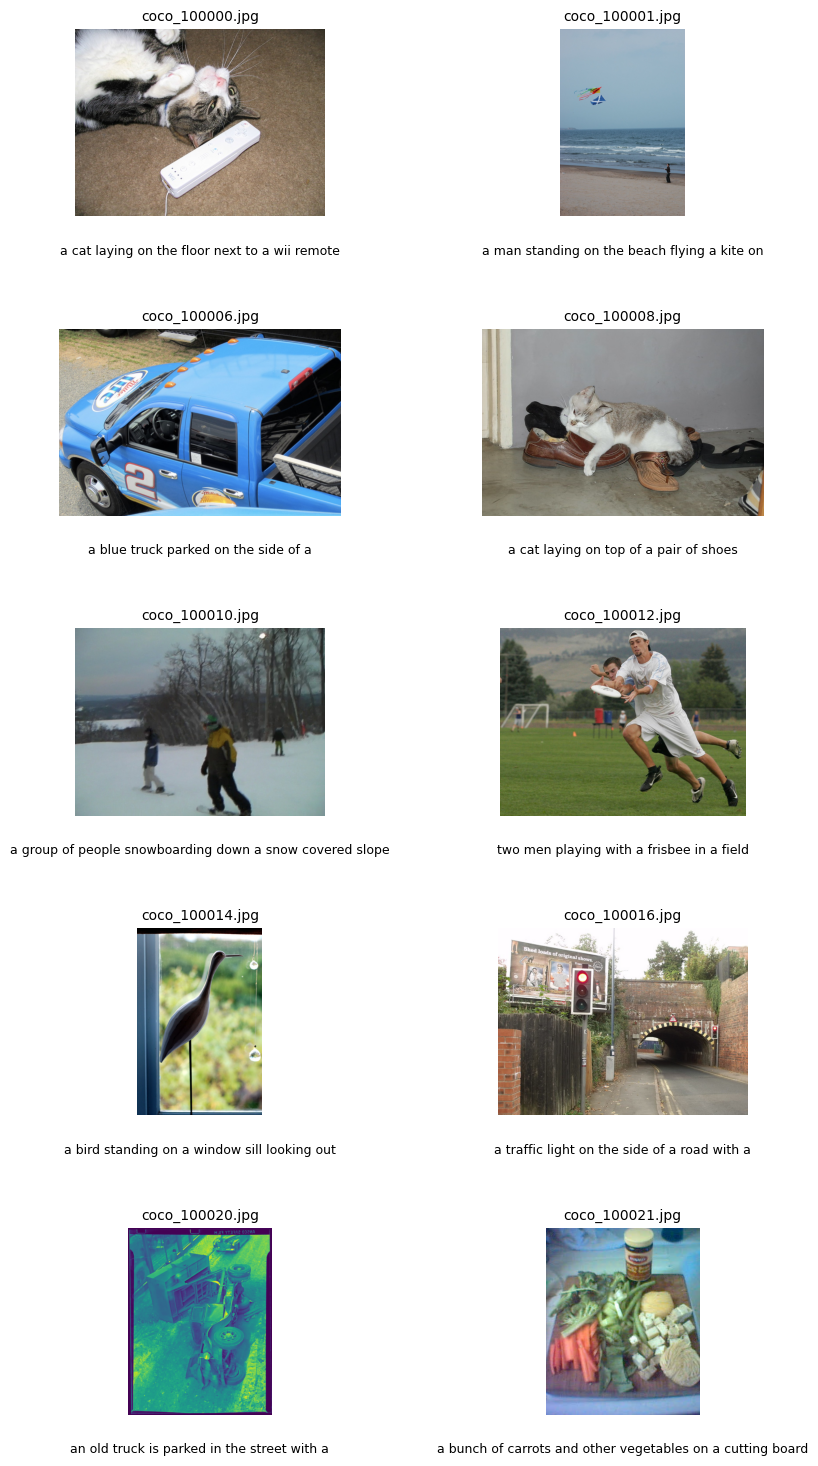

In [708]:
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device('cpu')

batch_size = 10
features_path = 'detections_10.hdf5'

image_field = ImageDetectionsField(detections_path=features_path, max_detections=50, load_in_tmp=False)

text_field = TextField(init_token='<bos>', eos_token='<eos>', lower=True, tokenize='spacy', remove_punctuation=True, nopoints=False)
with open('vocab_ipynb.pkl', 'rb') as f:
    data = pickle.load(f)
vocab = Vocab(Counter())
vocab.itos = data['itos']
vocab.stoi = defaultdict(lambda: 0, data['stoi'])

text_field.vocab = vocab

with h5py.File(features_path, 'r') as h5:
    image_ids = sorted(set(int(k.split('_')[0]) for k in h5.keys()))

examples = [Example.fromdict({'image': f'COCO_val2014_{str(image_id).zfill(12)}.jpg'}) for image_id in image_ids]

test_dataset = Dataset(examples, {'image': image_field})

dict_dataset_test = test_dataset
dict_dataloader_test = DataLoader(dict_dataset_test, batch_size=batch_size, num_workers=0)

encoder = MemoryAugmentedEncoder(3, 0, attention_module=ScaledDotProductAttentionEncoder, attention_module_kwargs={'m': 40})
decoder = MeshedDecoder(len(text_field.vocab), 54, 3, text_field.vocab.stoi['<pad>'])
model = Transformer(text_field.vocab.stoi['<bos>'], encoder, decoder).to(device)

data = torch.load('meshed_memory_transformer.pth', map_location=device)
model.load_state_dict(data['state_dict'])

generate_captions(model, dict_dataloader_test, text_field, device, test_dataset)